# House Price Prediction using Machine Learning

## Overview
This project aims to predict house prices based on various property features using Machine Learning. The dataset is preprocessed and cleaned before training a Linear Regression model. The model is then evaluated and used to predict house prices based on input features.

### Objectives
- Load and explore the dataset
- Clean and preprocess the data
- Train a Linear Regression model
- Predict house prices
- Evaluate model performance

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

1. Upload Dataset

In [1]:
from google.colab import files
uploaded = files.upload()

Saving enhanced_house_price_dataset.csv to enhanced_house_price_dataset.csv


2.Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

3. Load Dataset

In [3]:
df = pd.read_csv('enhanced_house_price_dataset.csv')

df.head()

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,City,Furnishing,Main Road,Guest Room,Basement,Water Supply,Air Conditioning,Preferred Tenant,Locality Rating,Price
0,1260,4,3,2,1,24,Pune,Semi-Furnished,Yes,Yes,Yes,Both,No,Company,4,1274350
1,5790,2,1,1,1,7,Kolkata,Unfurnished,Yes,Yes,Yes,Both,Yes,Bachelor,5,1094846
2,5626,5,2,3,0,15,Chennai,Semi-Furnished,No,Yes,Yes,Corporation,Yes,Company,6,1495933
3,5591,1,1,1,1,47,Delhi,Furnished,Yes,No,Yes,Borewell,No,Company,3,1003442
4,4172,5,1,1,1,44,Delhi,Unfurnished,No,No,No,Borewell,Yes,Bachelor,1,1306676


4. Explore Dataset

In [4]:
print("Dataset Shape:", df.shape)
df.info()
df.describe()
print(df.columns)

Dataset Shape: (2000, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Area              2000 non-null   int64 
 1   Bedrooms          2000 non-null   int64 
 2   Bathrooms         2000 non-null   int64 
 3   Stories           2000 non-null   int64 
 4   Parking           2000 non-null   int64 
 5   Age               2000 non-null   int64 
 6   City              2000 non-null   object
 7   Furnishing        2000 non-null   object
 8   Main Road         2000 non-null   object
 9   Guest Room        2000 non-null   object
 10  Basement          2000 non-null   object
 11  Water Supply      2000 non-null   object
 12  Air Conditioning  2000 non-null   object
 13  Preferred Tenant  2000 non-null   object
 14  Locality Rating   2000 non-null   int64 
 15  Price             2000 non-null   int64 
dtypes: int64(8), object(8)
memory usag

5. Convert Categorical Columns into Numbers

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = [
    'City',
    'Furnishing',
    'Main Road',
    'Guest Room',
    'Basement',
    'Water Supply',
    'Air Conditioning',
    'Preferred Tenant'
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,City,Furnishing,Main Road,Guest Room,Basement,Water Supply,Air Conditioning,Preferred Tenant,Locality Rating,Price
0,1260,4,3,2,1,24,6,1,1,1,1,1,0,1,4,1274350
1,5790,2,1,1,1,7,4,2,1,1,1,1,1,0,5,1094846
2,5626,5,2,3,0,15,1,1,0,1,1,2,1,1,6,1495933
3,5591,1,1,1,1,47,2,0,1,0,1,0,0,1,3,1003442
4,4172,5,1,1,1,44,2,2,0,0,0,0,1,0,1,1306676


6. Define Features and Target

In [6]:
X = df.drop('Price', axis=1)
y = df['Price']
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (2000, 15)
Target Shape: (2000,)


7. Split the Dataset

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1600, 15)
Testing Data: (400, 15)


8. Train Linear Regression Model

In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


9. Make Predictions

In [9]:
y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[1005194.27592821 1363694.04935222 1358393.68388541  825844.0952245
  989566.19679372 1132142.49159606 1388280.76240435 1263278.75231625
  774783.83063461 1650772.02566039]


10. Evaluate the Model

In [10]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 20012562271.534534
R² Score: 0.7792130781487583


11. Visualize Results

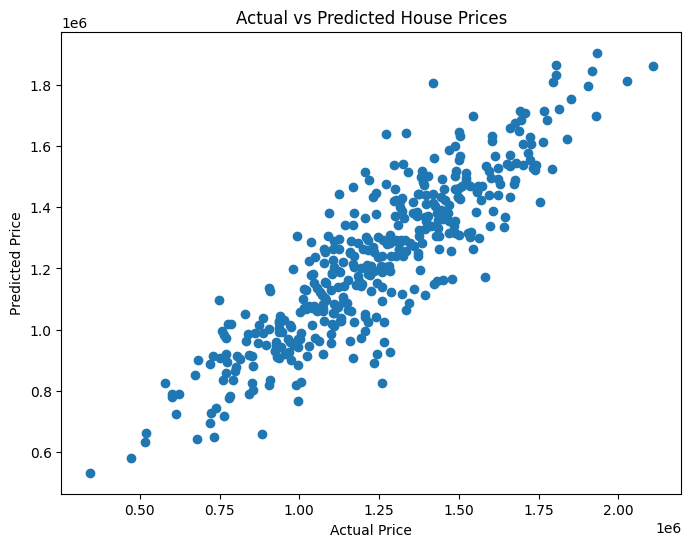

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

12. Predict a New House Price

In [12]:
new_house = [[
    2500,  # Area
    4,     # Bedrooms
    3,     # Bathrooms
    2,     # Stories
    2,     # Parking
    5,     # Age
    1,     # City
    1,     # Furnishing
    1,     # Main Road
    1,     # Guest Room
    0,     # Basement
    1,     # Water Supply
    1,     # Air Conditioning
    1,     # Preferred Tenant
    8      # Locality Rating
]]

predicted_price = model.predict(new_house)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 1641427.159191015


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


13.  Conclusion

A House Price Prediction model was successfully developed using Linear Regression.The dataset was preprocessed by converting categorical features into numerical values and splitting the data into training and testing sets.The model achieved an R² Score of 0.7792, indicating that it can explain approximately 78% of the variation in house prices. This demonstrates that the model performs reasonably well in predicting house prices based on the given features.The project provided practical experience in data preprocessing, machine learning model training, prediction, and performance evaluation using Python and Scikit-learn.